# CNN：卷积神经网络

上一篇文章实现了 MLP，它在 Digits（8×8）上表现不错。但 MLP 处理图像有个致命问题：参数数量随输入尺寸平方增长，一张 256×256 的图就能让全连接层爆炸到上亿参数。

CNN（卷积神经网络）用两个核心思路解决这个问题：**局部连接**和**权值共享**。本文用 NumPy 实现一个简单的 CNN，在 MNIST 手写数字（28×28）上验证效果，并与 MLP 做对比。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.cnn import CNN
from models.mlp import MLP

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 数据集：MNIST

MNIST 是 28×28 的灰度手写数字图，共 10 个类别（0-9），训练集 60000 张，测试集 10000 张。numpy 实现的 CNN 训练较慢，这里取 2000 张训练、1000 张测试。

In [2]:
print('Loading MNIST...')
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
y = y.astype(int)
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1000, random_state=42, stratify=y
)
X_train = X_train[:2000]
y_train = y_train[:2000]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Classes: {np.unique(y_train)}')

Loading MNIST...


Train: (2000, 784), Test: (1000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]


### 展示几个样本

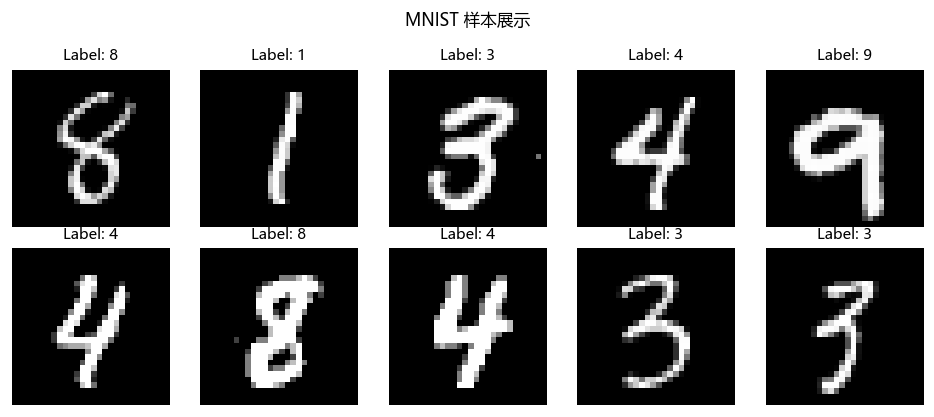

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('MNIST 样本展示', fontsize=10)
plt.tight_layout()
plt.show()

## 2. 训练 CNN

网络结构：

```
Input: 28×28×1
  ↓
Conv2D(1→8, 3×3, pad=1) → ReLU → MaxPool(2×2)  → 14×14×8
  ↓
Conv2D(8→16, 3×3, pad=1) → ReLU → MaxPool(2×2) → 7×7×16
  ↓
Flatten → Dense(128) → ReLU → Dense(10) → Softmax
```

In [ ]:
cnn = CNN(epochs=200, lr=0.2)
cnn.summary()

print('Training CNN...')
cnn.fit(X_train, y_train)

y_pred = cnn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'CNN test accuracy: {acc:.4f}')

### 损失曲线

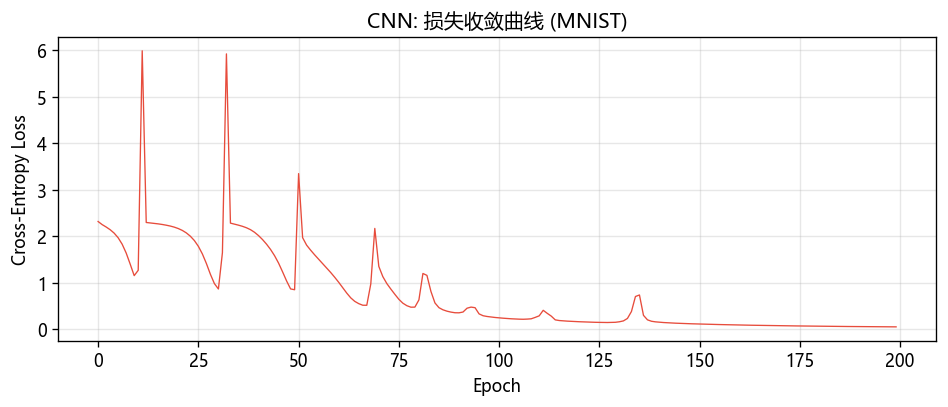

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(cnn.losses_, color='#e74c3c', lw=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('CNN: 损失收敛曲线 (MNIST)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 混淆矩阵

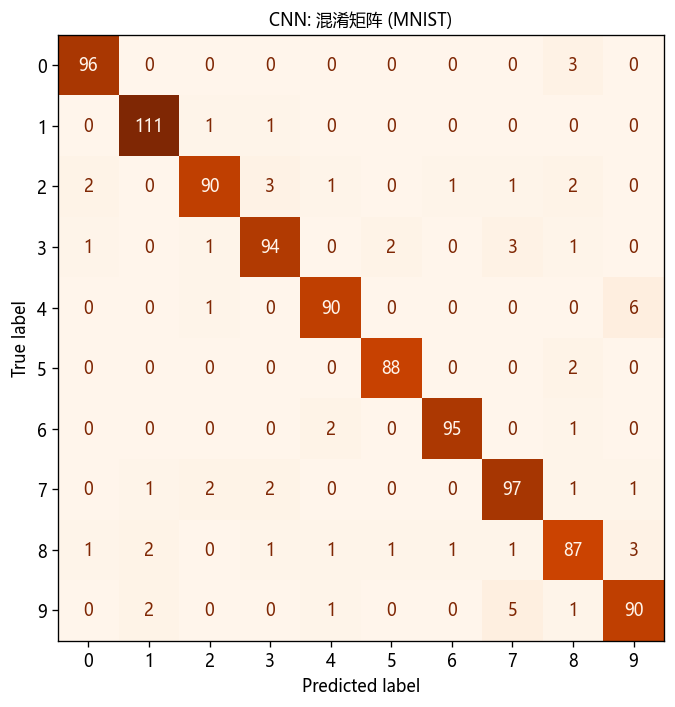

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('CNN: 混淆矩阵 (MNIST)', fontsize=10)
plt.tight_layout()
plt.show()

### 特征图可视化

将第一层卷积的输出（8 个通道）可视化，看看网络学到了什么特征。

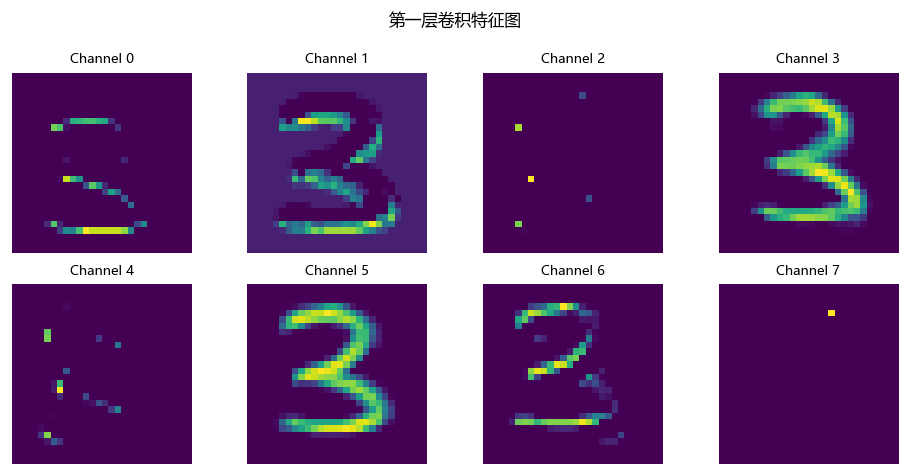

In [7]:
def vis_feature_maps(model, X_img):
    """Run one image through the first conv + relu and show 8 channels."""
    out = model.layers[0].forward(X_img[np.newaxis, :])  # Conv
    out = model.layers[1].forward(out)                    # ReLU
    maps = out[0]  # (8, H, W)

    fig, axes = plt.subplots(2, 4, figsize=(8, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(maps[i], cmap='viridis')
        ax.set_title(f'Channel {i}', fontsize=8)
        ax.axis('off')
    plt.suptitle('第一层卷积特征图', fontsize=10)
    plt.tight_layout()
    plt.show()

vis_feature_maps(cnn, X_test[0].reshape(1, 28, 28))

### 预测效果展示

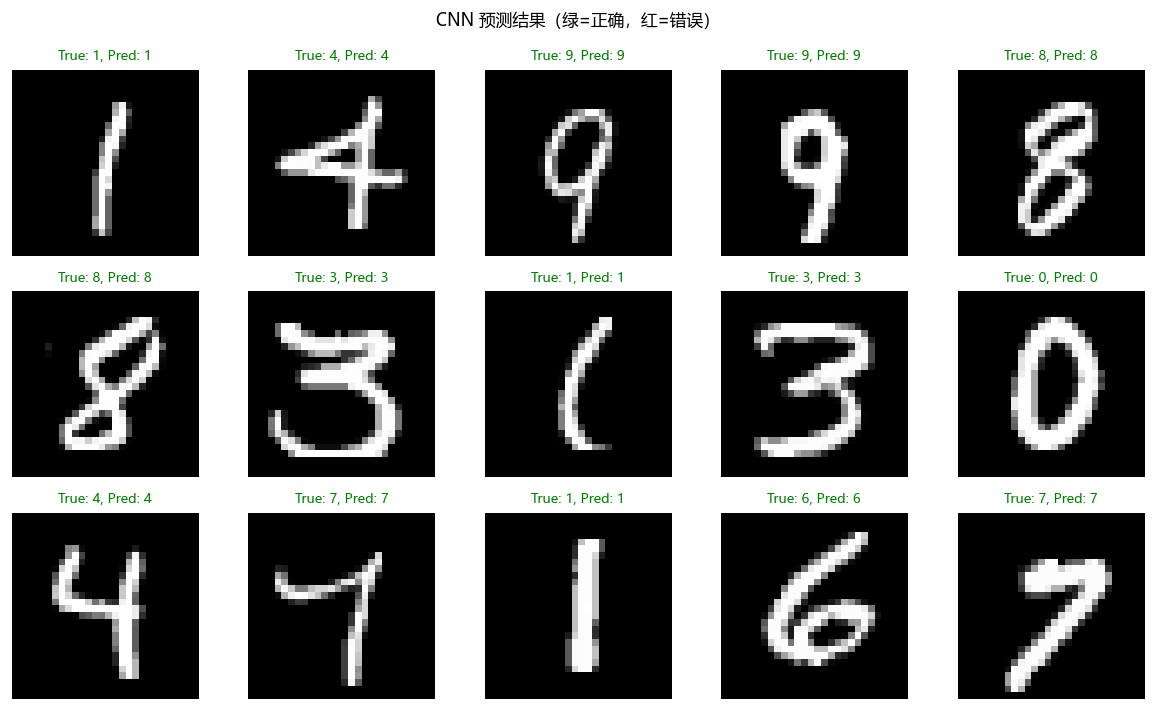

In [8]:
n_show = 15
indices = np.random.choice(len(X_test), n_show, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    ax.set_title(f'True: {y_test[idx]}, Pred: {y_pred[idx]}', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('CNN 预测结果（绿=正确，红=错误）', fontsize=10)
plt.tight_layout()
plt.show()

## 3. 对比：CNN vs MLP

在相同的数据集上训练 MLP（[784, 128, 10]），对比两种模型的效果。

In [9]:
# MLP baseline
mlp = MLP(layer_dims=[784, 128, 10], lr=0.1, epochs=200)
print('Training MLP...')
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
mlp.fit(X_train_std, y_train)

y_pred_mlp = mlp.predict(X_test_std)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f'MLP test accuracy: {acc_mlp:.4f}')
print(f'CNN test accuracy: {acc:.4f}')

Training MLP...


MLP test accuracy: 0.8830
CNN test accuracy: 0.9380


### 对比柱状图

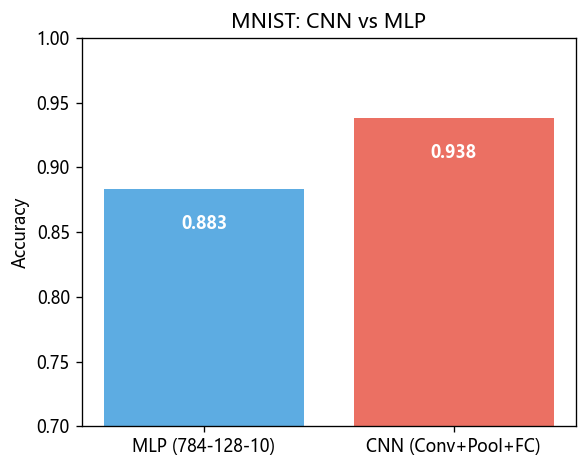

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['MLP (784-128-10)', 'CNN (Conv+Pool+FC)'], [acc_mlp, acc],
              color=['#3498db', '#e74c3c'], alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('MNIST: CNN vs MLP')
ax.set_ylim(0.7, 1.0)
for bar, val in zip(bars, [acc_mlp, acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
            f'{val:.3f}', ha='center', va='top', fontsize=10, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

## 小结

- **CNN** 用局部连接 + 权值共享解决了全连接层的参数爆炸问题
- 在 MNIST 上，CNN 在更少参数（~110K vs ~100K for MLP）下取得了比 MLP 更高的准确率
- 卷积层自动学习空间特征（边缘、纹理、形状），无需人工特征工程
- 过拟合风险依然存在——更大的数据集和更深的网络需要正则化（Dropout, BatchNorm）

下一步：尝试更深的结构，或引入现代 CNN 中的关键技巧（ResNet, BatchNorm, Data Augmentation）。